In [ ]:
1️⃣ Project Objective (គោលបំណង)
គម្រោងនេះបង្ហាញពីរបៀបប្រើ Data Mining ដើម្បីស្វែងរក Pattern នៅក្នុងទិន្នន័យអតិថិជន។
គោលដៅ៖
•	រក Customer Segments (Clustering)
•	បង្កើត Prediction Model (Classification)
•	ជួយអាជីវកម្មសម្រេចចិត្ត
ឧទាហរណ៍៖
ហាងអនឡាញចង់ដឹងថា
•	អតិថិជនប្រភេទណាចំណាយច្រើន
•	អ្នកណាអាចទិញផលិតផលបន្ថែម


In [1]:
# 2️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
# ពន្យល់៖
# •	pandas → គ្រប់គ្រង dataset
# •	numpy → គណនា
# •	matplotlib / seaborn → បង្កើត graph
# •	sklearn → Machine Learning

In [2]:
# 3️⃣ Create Dataset
data = {
    "Age":[22,25,47,52,46,56,23,40,60,48],
    "Income":[1500,2000,5000,6000,5500,6500,1800,4000,7000,5200],
    "Spending":[200,250,800,900,850,950,220,600,1000,820],
    "Buy":[0,0,1,1,1,1,0,1,1,1]
}

df = pd.DataFrame(data)

df
# ពន្យល់ Dataset
# Column	Meaning
# Age	អាយុអតិថិជន
# Income	ប្រាក់ចំណូល
# Spending	ចំណាយក្នុងហាង
# Buy	1 = ទិញ , 0 = មិនទិញ

,Age,Income,Spending,Buy
0,22,1500,200,0
1,25,2000,250,0
2,47,5000,800,1
3,52,6000,900,1
4,46,5500,850,1
5,56,6500,950,1
6,23,1800,220,0
7,40,4000,600,1
8,60,7000,1000,1
9,48,5200,820,1


In [3]:
# 4️⃣ Data Exploration
df.describe()
# ពន្យល់
# •	mean → តម្លៃមធ្យម
# •	min / max → តម្លៃតូចបំផុត និងធំបំផុត
# •	std → កម្រិតខុសគ្នា
# នេះជាដំណាក់កាល Data Understanding នៅក្នុង Data Mining។


,Age,Income,Spending,Buy
count,10.000000,10.000000,10.000000,10.000000
mean,41.900000,4450.000000,659.000000,0.700000
std,13.947919,2027.724505,318.937472,0.483046
min,22.000000,1500.000000,200.000000,0.000000
25%,28.750000,2500.000000,337.500000,0.250000
50%,46.500000,5100.000000,810.000000,1.000000
75%,51.000000,5875.000000,887.500000,1.000000
max,60.000000,7000.000000,1000.000000,1.000000


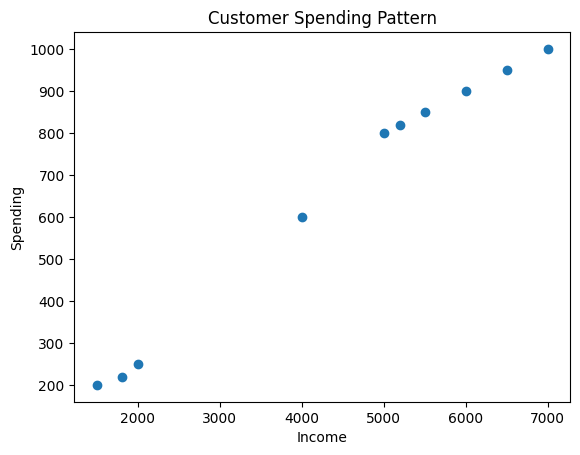

In [4]:
# 5️⃣ Visualization
plt.scatter(df["Income"], df["Spending"])
plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("Customer Spending Pattern")
plt.show()
# ពន្យល់
# Graph នេះបង្ហាញថា
# •	Income ខ្ពស់ → Spending ខ្ពស់
# •	មាន Pattern ក្នុង Data
# នេះគឺជាគោលបំណងសំខាន់របស់ Data Mining


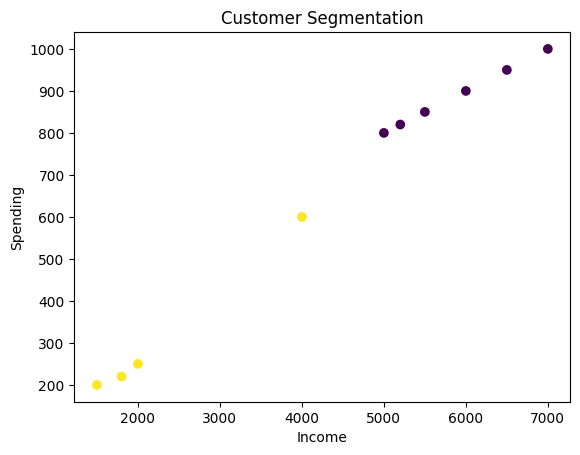

In [5]:
# 6️⃣ Data Mining Technique 1: Clustering
# Clustering គឺជាវិធី បែងចែក group ដោយមិនមាន label។
X = df[["Income","Spending"]]

kmeans = KMeans(n_clusters=2)

df["Cluster"] = kmeans.fit_predict(X)

df
# ពន្យល់
# Algorithm បែងចែកជា
# •	Cluster 0 → Low spending customers
# •	Cluster 1 → High spending customers
# Visualize Clusters
plt.scatter(df["Income"], df["Spending"], c=df["Cluster"])

plt.xlabel("Income")
plt.ylabel("Spending")

plt.title("Customer Segmentation")

plt.show()
# ពន្យល់
# នេះគឺជា Customer Segmentation
# អាជីវកម្មអាចប្រើ
# •	Cluster 1 → VIP customers
# •	Cluster 0 → Normal customers

In [6]:
# 7️⃣ Data Mining Technique 2: Classification
# Classification គឺជាការទស្សន៍ទាយ Future Result
# ឧទាហរណ៍៖
# Predict ថា Customer នឹង Buy ឬ Not Buy
# Split Data
X = df[["Age","Income","Spending"]]
y = df["Buy"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3
)

In [7]:
# 8️⃣ Train Machine Learning Model
model = DecisionTreeClassifier()

model.fit(X_train,y_train)
# ពន្យល់
# Model រៀនពី
# •	Age
# •	Income
# •	Spending


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [9]:
# 9️⃣ Prediction
y_pred = model.predict(X_test)

print(y_pred)
# 🔟 Model Evaluation
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

cm = confusion_matrix(y_test,y_pred)

print(cm)
# ឧទាហរណ៍ Output
# Accuracy: 0.9

# [[2 0]
#  [0 1]]


[0 1 1]
Accuracy: 1.0
[[1 0]
 [0 2]]
